In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
url = "https://raw.githubusercontent.com/Shyam414/Uber-ETL/master/uber_dataset/uber_data.csv"
data = pd.read_csv(url)

# Inspect the dataset
print("First 5 rows of the dataset:")
print(data.head())
print("\nData types and null values:")
print(data.info())

# Check for missing values
print("\nMissing values in the dataset:")
print(data.isnull().sum())

# Convert date-time fields
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])

# Handle missing or inconsistent values (if any)
data.dropna(inplace=True)

# Convert categorical 'store_and_fwd_flag' to numerical
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

# Summary statistics
print("\nSummary statistics:")
print(data.describe())



First 5 rows of the dataset:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2016-03-01 00:00:00   2016-03-01 00:07:55                1   
1         1  2016-03-01 00:00:00   2016-03-01 00:11:06                1   
2         2  2016-03-01 00:00:00   2016-03-01 00:31:06                2   
3         2  2016-03-01 00:00:00   2016-03-01 00:00:00                3   
4         2  2016-03-01 00:00:00   2016-03-01 00:00:00                5   

   trip_distance  pickup_longitude  pickup_latitude  RatecodeID  \
0           2.50        -73.976746        40.765152           1   
1           2.90        -73.983482        40.767925           1   
2          19.98        -73.782021        40.644810           1   
3          10.78        -73.863419        40.769814           1   
4          30.43        -73.971741        40.792183           3   

  store_and_fwd_flag  dropoff_longitude  dropoff_latitude  payment_type  \
0                  N         -74.004265   

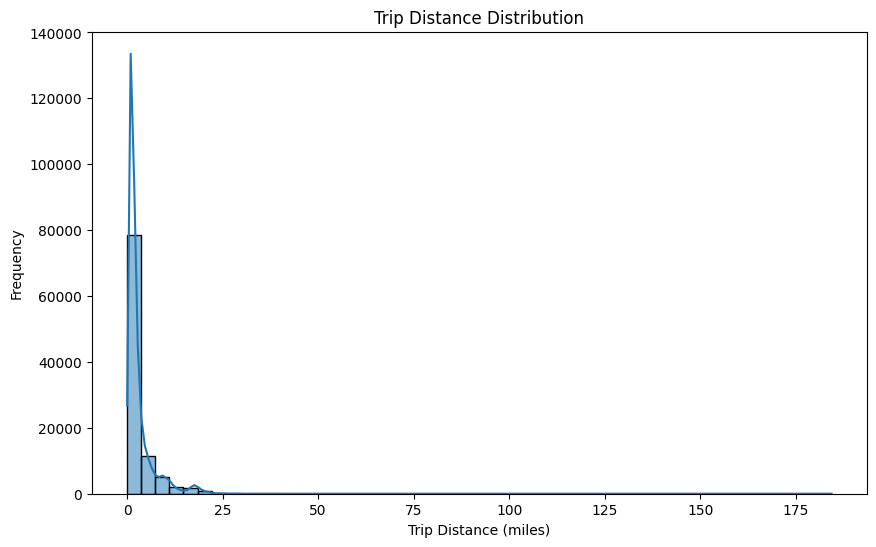

In [2]:
# Visualize distributions
plt.figure(figsize=(10, 6))
sns.histplot(data['trip_distance'], bins=50, kde=True)
plt.title('Trip Distance Distribution')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Frequency')
plt.show()



In [3]:
data.corr()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
VendorID,1.000000,0.660490,0.660578,0.176117,-0.077696,-0.025754,0.026333,-0.029439,-0.096925,-0.024983,0.024801,-0.058178,-0.020604,-0.595922,0.016772,0.008747,0.006171,-0.011010,-0.022746
tpep_pickup_datetime,0.660490,1.000000,0.999943,0.113928,-0.126273,-0.027430,0.028249,-0.045500,-0.063950,-0.025268,0.024953,-0.074933,-0.037660,-0.914532,0.025831,0.009827,0.010012,0.004265,-0.040367
tpep_dropoff_datetime,0.660578,0.999943,1.000000,0.113899,-0.124715,-0.027478,0.028298,-0.045002,-0.063944,-0.025307,0.024991,-0.075003,-0.036047,-0.914519,0.025792,0.010706,0.011013,0.004325,-0.038796
passenger_count,0.176117,0.113928,0.113899,1.000000,-0.016795,-0.003019,0.003171,-0.018723,-0.016308,-0.002742,0.002721,-0.008660,-0.010090,-0.097992,0.008736,-0.002748,-0.002484,-0.003391,-0.010278
trip_distance,-0.077696,-0.126273,-0.124715,-0.016795,1.000000,-0.012553,0.013158,0.409197,0.018684,-0.011187,0.011907,-0.069641,0.892986,0.068782,-0.106126,0.576482,0.643106,0.022076,0.896080
pickup_longitude,-0.025754,-0.027430,-0.027478,-0.003019,-0.012553,1.000000,-0.998653,0.109419,0.002617,0.898903,-0.897898,0.010226,0.018074,0.017925,-0.055602,0.007851,-0.007107,-0.023494,0.015355
pickup_latitude,0.026333,0.028249,0.028298,0.003171,0.013158,-0.998653,1.000000,-0.109446,-0.002640,-0.898295,0.899104,-0.009975,-0.017349,-0.018799,0.055595,-0.007388,0.008335,0.023443,-0.014567
RatecodeID,-0.029439,-0.045500,-0.045002,-0.018723,0.409197,0.109419,-0.109446,1.000000,0.013021,0.077950,-0.078441,-0.025299,0.541713,-0.056559,-0.501237,0.338899,0.435579,-0.021094,0.543730
store_and_fwd_flag,-0.096925,-0.063950,-0.063944,-0.016308,0.018684,0.002617,-0.002640,0.013021,1.000000,0.011880,-0.011807,0.011875,0.013488,0.055365,-0.004182,0.001544,0.006982,0.001067,0.012700
dropoff_longitude,-0.024983,-0.025268,-0.025307,-0.002742,-0.011187,0.898903,-0.898295,0.077950,0.011880,1.000000,-0.999039,0.013573,0.018492,0.018189,-0.042321,0.006630,-0.002685,-0.022107,0.015984


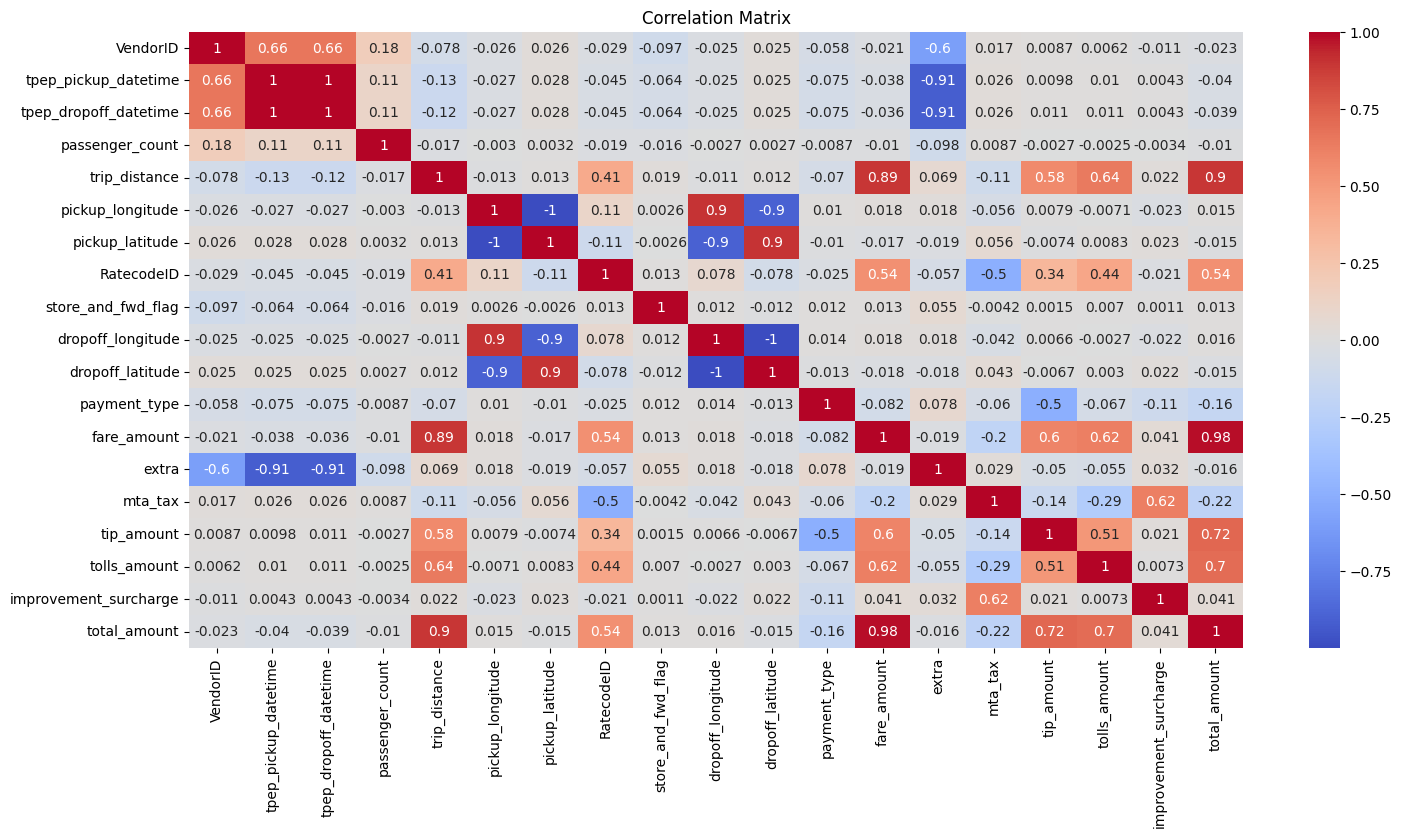

In [4]:
# Correlation matrix
plt.figure(figsize=(17, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [5]:
# Create new features
data['trip_duration'] = (data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Normalize numerical features if necessary
scaler = StandardScaler()
data[['trip_distance', 'trip_duration']] = scaler.fit_transform(data[['trip_distance', 'trip_duration']])

# Analyze key metrics
average_fare = data['total_amount'].mean()
average_trip_distance = data['trip_distance'].mean()
average_tip = data['tip_amount'].mean()

print(f'\nAverage Fare: ${average_fare:.2f}')
print(f'Average Trip Distance: {average_trip_distance:.2f} (standardized)')
print(f'Average Tip: ${average_tip:.2f}')


Average Fare: $16.39
Average Trip Distance: 0.00 (standardized)
Average Tip: $1.87


In [6]:
# Define the problem (e.g., predicting total amount)
features = ['trip_distance', 'trip_duration', 'passenger_count']
target = 'total_amount'

X = data[features]
y = data[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')



MAE: 2.84
RMSE: 5.67
R²: 0.84


C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


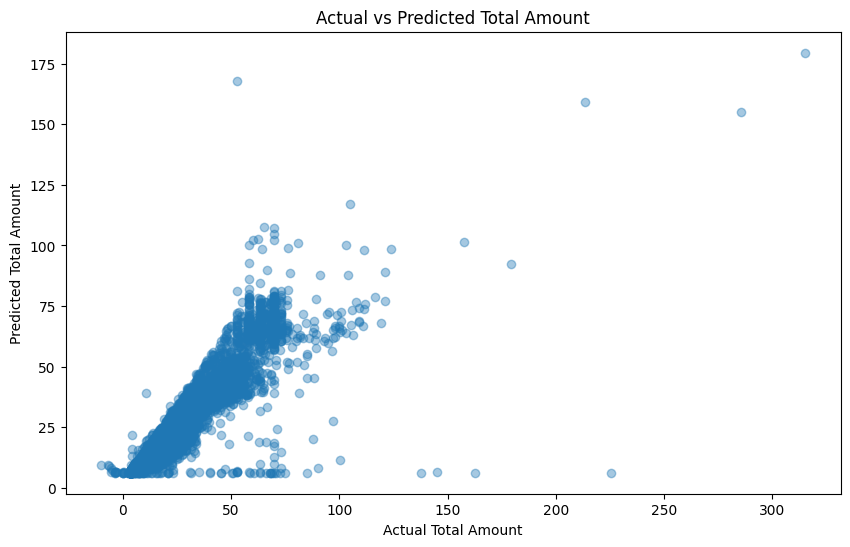

In [7]:
# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Total Amount')
plt.show()


In [8]:
# Define the problem (e.g., predicting total amount)
features = ['trip_distance', 'trip_duration', 'passenger_count']
target = 'total_amount'

X = data[features]
y = data[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = Ridge()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')



MAE: 2.84
RMSE: 5.67
R²: 0.84


C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


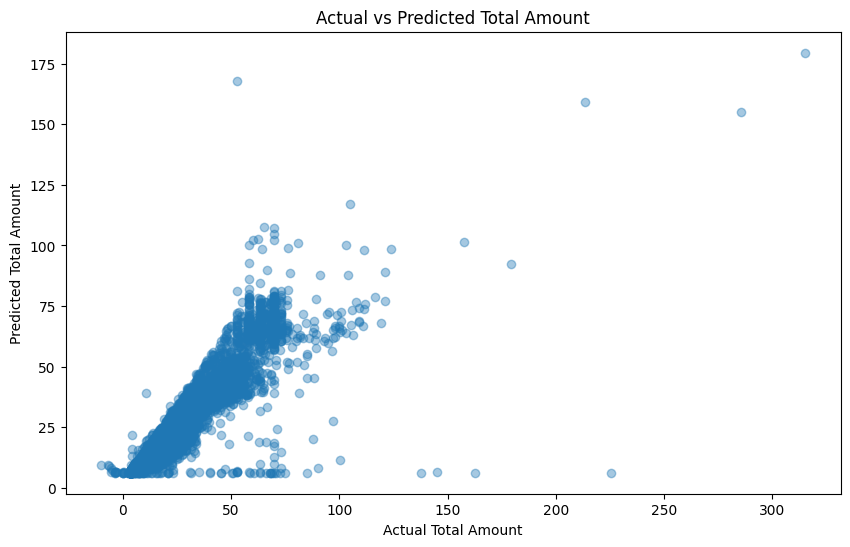

In [9]:
# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Total Amount')
plt.show()


In [10]:
# Define the problem (e.g., predicting total amount)
features = ['trip_distance', 'trip_duration', 'passenger_count']
target = 'total_amount'

X = data[features]
y = data[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = Lasso()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')



MAE: 3.00
RMSE: 5.81
R²: 0.83


C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


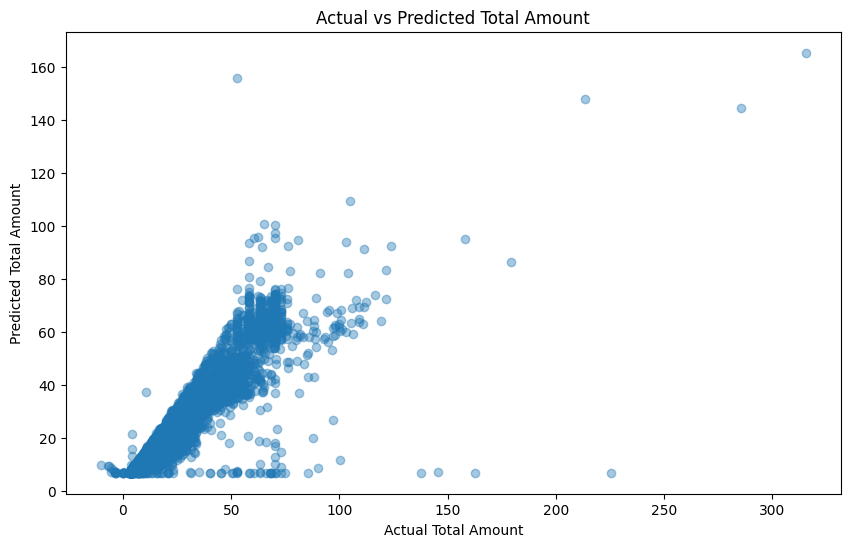

In [11]:
# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Total Amount')
plt.show()


In [12]:
# Define the problem (e.g., predicting total amount)
features = ['trip_distance', 'trip_duration', 'passenger_count']
target = 'total_amount'

X = data[features]
y = data[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')



MAE: 2.54
RMSE: 9.30
R²: 0.57


C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


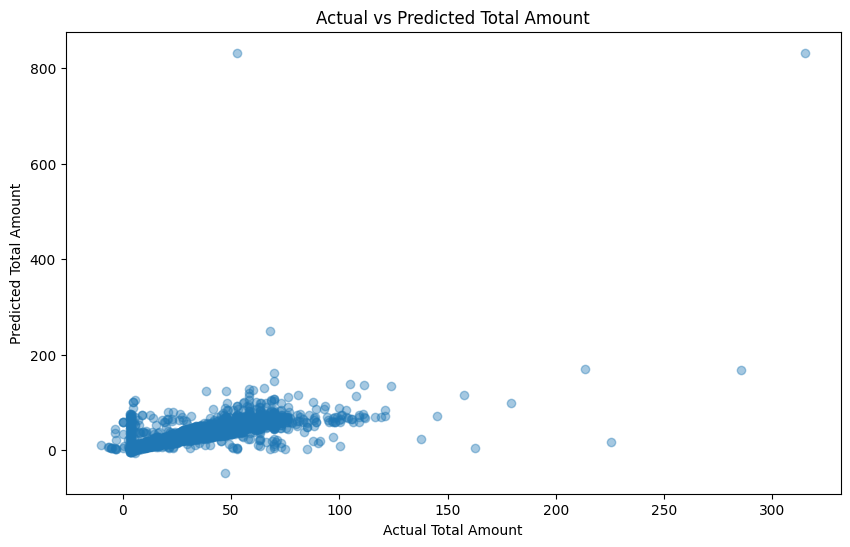

In [13]:
# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Total Amount')
plt.show()


In [14]:
# Define the problem (e.g., predicting total amount)
features = ['trip_distance', 'trip_duration', 'passenger_count']
target = 'total_amount'

X = data[features]
y = data[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'\nMAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.2f}')



MAE: 2.05
RMSE: 5.65
R²: 0.84


C:\Users\sunda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


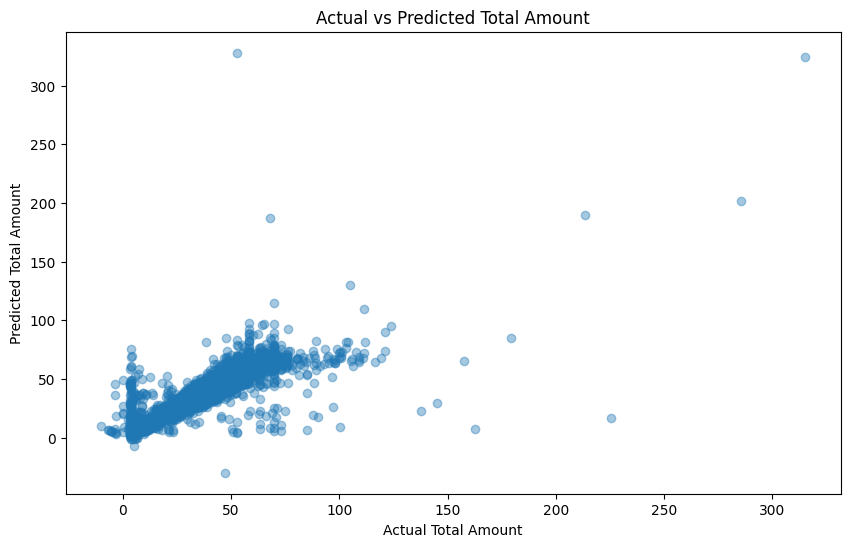

In [15]:
# Visualize the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Total Amount')
plt.ylabel('Predicted Total Amount')
plt.title('Actual vs Predicted Total Amount')
plt.show()


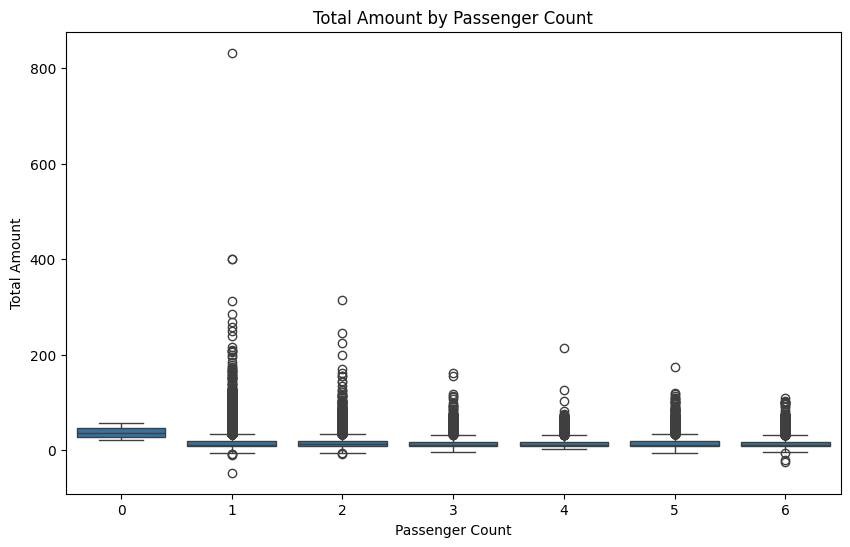

In [16]:

# Additional analysis and insights
plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='total_amount', data=data)
plt.title('Total Amount by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Total Amount')
plt.show()



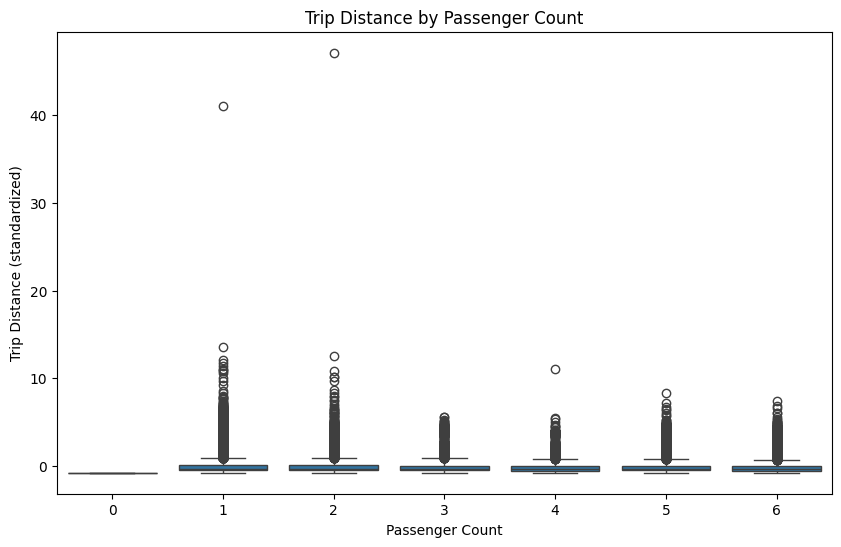

In [17]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='trip_distance', data=data)
plt.title('Trip Distance by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Distance (standardized)')
plt.show()